# 👩‍💻 Grouping Airline Customers Using Hierarchical Clustering

## 📋 Overview
In this lab, you’ll implement **Hierarchical Clustering** to group customers from the **Airline Customer Segmentation Dataset**. You’ll build dendrograms, experiment with different linkage methods, and compare how hierarchical clusters relate to K-Means clusters.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

 - Preprocess airline customer data for clustering
 
 - Apply hierarchical clustering using different linkage methods
 
 - Visualize clustering processes through dendrograms
 
 - Analyze and interpret customer groups

## Task 1: Load and Explore the Airline Dataset
**Context:** Understand what your customer data looks like before modeling.

**Steps:**

1. Load the dataset using Pandas.


2. Use `.head()`, `.info()`, and `.describe()` to explore the dataset.


3. Focus on features like `Flight Distance`, `Seat comfort`, `Checkin service`. Also note that some variables are numerical and others are categorical. They may need different treatment.


**Prompting Questions:**

- Are the important attributes present and clean?


- Are any features categorical (non-numeric)?


💡 **Tip:** Hierarchical clustering works best with numeric features!


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load the dataset
data = pd.read_csv('Airline_Customers.csv')  # Adjust filename/path as needed
data = data.sample(n=10000, random_state=42).reset_index(drop=True) # Reduce sample size for compute reasons

# Preview the data
# <your code here>
print(data.shape)
data.head(2)

(10000, 23)


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,59,Business travel,Business,1470,4,4,4,...,4,4,4,4,4,5,4,3,7,0.0
1,dissatisfied,Female,disloyal Customer,22,Business travel,Eco,1771,1,1,1,...,5,4,3,4,3,1,4,4,0,0.0


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   satisfaction                       10000 non-null  object 
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Seat comfort                       10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Food and drink                     10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Inflight wifi service              10000 non-null  int6

In [3]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,39.276200,15.074602,7.0,27.00,40.0,51.0,85.0
Flight Distance,10000.0,1984.692100,1034.001040,50.0,1346.75,1920.0,2558.0,6951.0
Seat comfort,10000.0,2.836600,1.400820,0.0,2.00,3.0,4.0,5.0
Departure/Arrival time convenient,10000.0,3.006000,1.532905,0.0,2.00,3.0,4.0,5.0
Food and drink,10000.0,2.852600,1.447993,0.0,2.00,3.0,4.0,5.0
Gate location,10000.0,2.991000,1.306327,1.0,2.00,3.0,4.0,5.0
Inflight wifi service,10000.0,3.249900,1.316671,0.0,2.00,3.0,4.0,5.0
Inflight entertainment,10000.0,3.379800,1.349939,0.0,2.00,4.0,4.0,5.0
Online support,10000.0,3.519700,1.306592,1.0,3.00,4.0,5.0,5.0
Ease of Online booking,10000.0,3.471700,1.307429,1.0,2.00,4.0,5.0,5.0


In [4]:
features= data[["Flight Distance", "Seat comfort", "Checkin service"]]

**⚙️ Test Your Work:**

- DataFrame loads and displays correctly

- Numerical features identified


## Task 2: Data Preprocessing

**Context:** Features must be on the same scale for distance-based clustering.

**Steps:**

1. Check for missing values (`.isnull().sum()`) and handle if necessary.


2. Select important numeric features only.


3. Standardize features using `StandardScaler()`.


**Prompting Questions:**
- Any missing or invalid data?

- Are the scales of the features wildly different?

💡 **Tip:** Standardized features will have mean 0 and standard deviation 1.

In [5]:
# Check for missing values
features.isnull().sum()

Flight Distance    0
Seat comfort       0
Checkin service    0
dtype: int64

In [6]:
# Drop rows with missing values (if any)
features = features.dropna()

In [7]:
# Standardize numerical features for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

**⚙️ Test Your Work:**
- No missing values

- Scaled dataset (`X_scaled`) ready for clustering

## Task 3: Perform Hierarchical Clustering
**Context:** Build the actual cluster relationships.

**Steps:**

1. Compute the linkage matrix using `linkage()` from SciPy.


2. Different linkage criteria:

     - `'ward'` (minimizes variance)

     - `'single'` (minimum distance)

     - `'complete'` (maximum distance)

     - `'average'` (average distance)


**Prompting Questions:**

- How does the linkage choice affect clustering?
- Does one method produce cleaner separations?
- How does the linkage choice affect the structure shown in the dendrogram?


💡 **Tip:** `'ward'` tends to produce the most balanced clusters.

In [8]:
# Perform hierarchical clustering with different linkage methods

# Compute linkage matrix using Ward's method
linked_ward = linkage(X_scaled, method='ward')

# Try other linkage methods
linked_single = linkage(X_scaled, method='single')
linked_complete = linkage(X_scaled, method='complete')
linked_average = linkage(X_scaled, method='average')

**⚙️ Test Your Work:**

- Linkage matrices created for each method

## Task 4: Visualize with a Dendrogram
**Context:** See the entire clustering process visually.

**Steps:**

1. Create a dendrogram plot using `dendrogram()`.


2. Label points with customer IDs or simple indexes.


3. Mark a threshold to visually suggest cutting into clusters.


**Prompting Questions:**
- Where do large vertical gaps appear?

- How many clusters seem natural?


💡 **Tip:** Set `truncate_mode='level'` or `p=5` to focus on top levels if the dendrogram is too detailed.

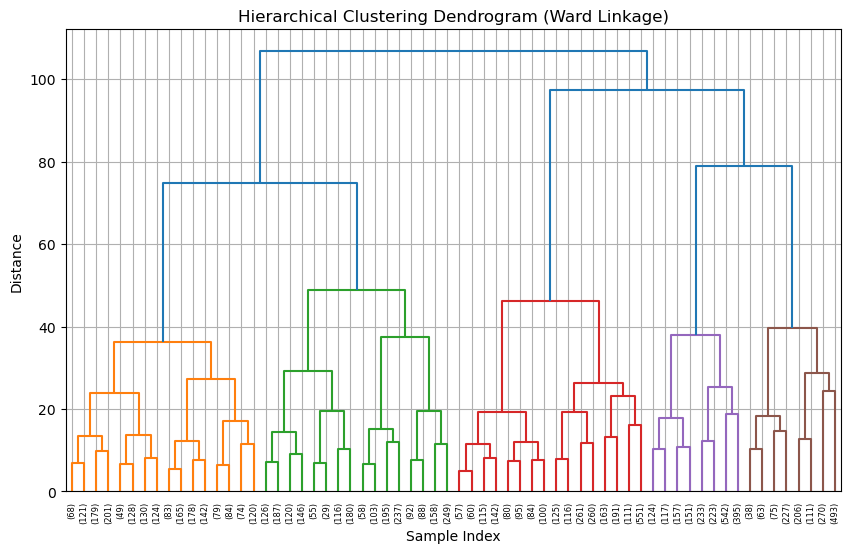

In [9]:
# Plot dendrogram for visualizing hierarchical clusters

plt.figure(figsize=(10, 6))
dendrogram(linked_ward, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

**⚙️ Test Your Work:**

-  Dendrogram plot is generated

- Suggested number of clusters is visible

## Task 5: Determine and Form Final Clusters
**Context:** Cut the dendrogram to create actual cluster assignments.

**Steps:**

1. Use `fcluster()` to assign data points to clusters based on a distance threshold or fixed number of clusters.


2. Add the cluster labels back to the original dataset.

**Prompting Questions:**
- How many final clusters did you choose?

- Are clusters fairly balanced?

💡 **Tip:** Try cutting at 3–6 clusters depending on the dendrogram structure.

In [10]:
# Assign customers to clusters using dendrogram cut

# Choose number of clusters based on dendrogram
n_clusters = 4

# Assign cluster labels
cluster_labels = fcluster(linked_ward, n_clusters, criterion='maxclust')

# Add cluster labels to original dataset
features['Cluster_Hierarchical'] = cluster_labels

**⚙️ Test Your Work:**

- Cluster labels added to DataFrame

## Task 6: Analyze the Clusters
**Context:** Translate clusters into meaningful business segments.

**Steps:**

1. Group and describe each cluster.


2. Compare average values for relevant features in each cluster, such as Flight Distance, Seat comfort, Checkin service etc.


3. Propose marketing strategies based on the different customer types.


**Prompting Questions:**
- Which clusters contain frequent flyers?

- Which clusters prefer comfort over cost?


💡 **Tip:** Use `.groupby('Cluster').mean()` for a quick overview.

,Flight Distance,Seat comfort,Checkin service
Cluster_Hierarchical,,,
1,1790.526821,3.333169,2.305118
2,1728.320191,3.749502,4.514934
3,1640.776519,1.267765,4.088568
4,3401.227242,1.984491,3.154417


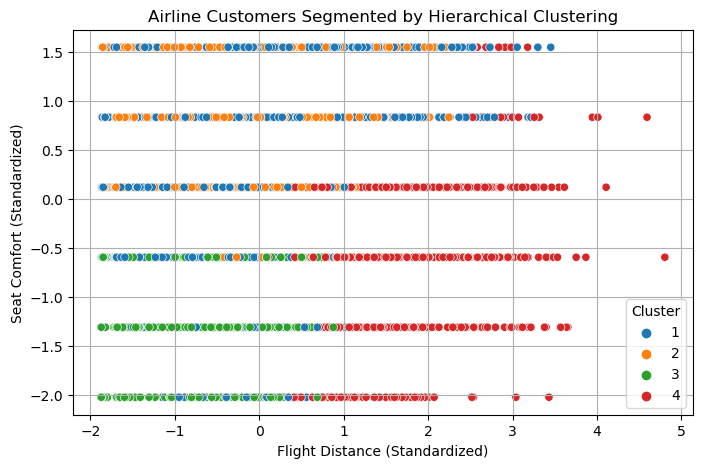

In [11]:
# Analyze and interpret characteristics of each cluster

# Add the cluster labels to full original dataset for broader analysis
data = data.loc[features.index]  # Align indices
data['Cluster_Hierarchical'] = cluster_labels

# Summarize by cluster
cluster_summary = data.groupby('Cluster_Hierarchical')[['Flight Distance', 'Seat comfort', 'Checkin service']].mean()
display(cluster_summary)

# Optional: Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X_scaled[:, 0],  # Flight Distance
    y=X_scaled[:, 1],  # Seat comfort
    hue=cluster_labels,
    palette='tab10'
)
plt.title('Airline Customers Segmented by Hierarchical Clustering')
plt.xlabel('Flight Distance (Standardized)')
plt.ylabel('Seat Comfort (Standardized)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()

**⚙️ Test Your Work:**
- Clear cluster profiles created

- Insights into customer types documented

## Bonus

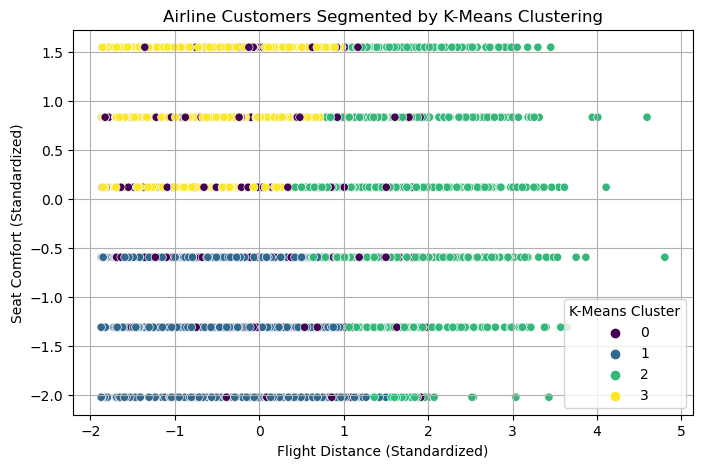

In [12]:
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

data['Cluster_KMeans'] = kmeans_labels

# Visualize K-Means clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)
plt.title('Airline Customers Segmented by K-Means Clustering')
plt.xlabel('Flight Distance (Standardized)')
plt.ylabel('Seat Comfort (Standardized)')
plt.grid(True)
plt.legend(title='K-Means Cluster')
plt.show()

## Reflections

**Cluster Observations :**

- Cluster 1: Long-distance flyers who value comfort
- Cluster 2: Short-haul travelers with average service ratings
- Cluster 3: Flyers who rate service low despite high distance
- Cluster 4: Balanced travelers with high ratings

**Business Insights :**

- Upsell luxury/premium services to Cluster 1
- Improve service engagement for Cluster 3
- Offer loyalty perks to Cluster 2 to increase retention

## ✅ Success Checklist

- Airline customer dataset loaded and explored

- Features standardized

- Linkage matrices calculated with different methods

- Dendrograms visualized

- Clusters assigned and interpreted

## 🔍 Common Issues & Solutions

**Problem:** Dendrogram too detailed to interpret

**Solution:** Truncate the dendrogram with `truncate_mode` or cut at a higher level
 
**Problem:** Clusters very imbalanced

**Solution:** Try different linkage methods (`ward` is often best for balanced clusters)
 
**Problem:** Strange cluster assignments

**Solution:** Ensure scaling is correctly applied to features

## 🔑 Key Points

- Hierarchical clustering builds a tree structure (dendrogram)


- Linkage method impacts cluster shape and size


- Visual inspection through dendrograms is crucial for understanding structure

## Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches.

Reflect on what you can learn from the exemplar solution to improve your coding skills.

Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.

Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>
<summary><strong>Click HERE to see an examplar solution</strong></summary>
    
```python

# -------------------------------
# Task 1: Load and Explore Dataset
# -------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load the dataset
data = pd.read_csv('Airline_Customers.csv')
# Subsample to 10000 rows
data = data.sample(n=10000, random_state=42).reset_index(drop=True)

# Preview the data
print(data.head())
print(data.info())
print(data.describe())

# Select relevant numerical features
features = data[['Flight Distance', 'Seat comfort', 'Checkin service']]

# -------------------------------
# Task 2: Data Preprocessing
# -------------------------------

# Check for missing values
print(features.isnull().sum())

# Drop rows with missing values (if any)
features = features.dropna()

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# -------------------------------
# Task 3: Perform Hierarchical Clustering
# -------------------------------

# Compute linkage matrix using Ward's method
linked_ward = linkage(X_scaled, method='ward')

# Try other linkage methods
linked_single = linkage(X_scaled, method='single')
linked_complete = linkage(X_scaled, method='complete')
linked_average = linkage(X_scaled, method='average')
    
# -------------------------------
# Task 4: Visualize with a Dendrogram
# -------------------------------

plt.figure(figsize=(10, 6))
dendrogram(linked_ward, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

# -------------------------------
# Task 5: Determine and Form Final Clusters
# -------------------------------

# Choose number of clusters based on dendrogram
n_clusters = 4

# Assign cluster labels
cluster_labels = fcluster(linked_ward, n_clusters, criterion='maxclust')

# Add cluster labels to original dataset
features['Cluster_Hierarchical'] = cluster_labels

# -------------------------------
# Task 6: Analyze the Clusters
# -------------------------------

# Add the cluster labels to full original dataset for broader analysis
data = data.loc[features.index]  # Align indices
data['Cluster_Hierarchical'] = cluster_labels

# Summarize by cluster
cluster_summary = data.groupby('Cluster_Hierarchical')[['Flight Distance', 'Seat comfort', 'Checkin service']].mean()
print(cluster_summary)

# Optional: Visualize clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X_scaled[:, 0],  # Flight Distance
    y=X_scaled[:, 1],  # Seat comfort
    hue=cluster_labels,
    palette='tab10'
)
plt.title('Airline Customers Segmented by Hierarchical Clustering')
plt.xlabel('Flight Distance (Standardized)')
plt.ylabel('Seat Comfort (Standardized)')
plt.grid(True)
plt.legend(title='Cluster')
plt.show()
    
# -------------------------------
# Bonus: Compare with K-Means Clustering
# -------------------------------

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

data['Cluster_KMeans'] = kmeans_labels

# Visualize K-Means clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=kmeans_labels,
    palette='viridis'
)
plt.title('Airline Customers Segmented by K-Means Clustering')
plt.xlabel('Flight Distance (Standardized)')
plt.ylabel('Seat Comfort (Standardized)')
plt.grid(True)
plt.legend(title='K-Means Cluster')
plt.show()

# -------------------------------
# Reflections / Observations
# -------------------------------

"""
Cluster Observations:
- Cluster 1: Long-distance flyers who value comfort
- Cluster 2: Short-haul travelers with average service ratings
- Cluster 3: Flyers who rate service low despite high distance
- Cluster 4: Balanced travelers with high ratings

Business Insights:
- Upsell luxury/premium services to Cluster 1
- Improve service engagement for Cluster 3
- Offer loyalty perks to Cluster 2 to increase retention
"""

```